# CV Project 2 — Multi-Task AI Image Detection


## STEP 1 — Setup

In [1]:
# Fix large image warning
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
print('PIL limit removed')

PIL limit removed


In [2]:
# All imports
import os, random, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU! Go to Runtime > Change runtime type > T4 GPU')
# Reproducibility
import numpy as np
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
print('Seeds set')

Device: cuda
GPU: Tesla T4
Seeds set


## STEP 2 — Download Dataset

In [3]:
!wget "https://zenodo.org/records/14963880/files/RRDataset_test.tar.gz?download=1" -O RRDataset_test.tar.gz
!tar -xzf RRDataset_test.tar.gz
!rm RRDataset_test.tar.gz
print('Dataset ready')

--2026-06-11 20:02:21--  https://zenodo.org/records/14963880/files/RRDataset_test.tar.gz?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.48.75, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20117869400 (19G) [application/octet-stream]
Saving to: ‘RRDataset_test.tar.gz’

RRDataset_test.tar. 100%[===================>]  18.74G  12.9MB/s    in 17m 2s  

2026-06-11 20:19:23 (18.8 MB/s) - ‘RRDataset_test.tar.gz’ saved [20117869400/20117869400]

Dataset ready


## STEP 3 — Data Pipeline

In [4]:
random.seed(42)

ROOT = 'RRDataset_final'
TRAIN_PER_BUCKET = 2000
VAL_PER_BUCKET   = 500

TRANSFORM_LABELS = {'original': 0, 'transfer': 1, 'redigital': 2}
REAL_FAKE_LABELS = {'ai': 0, 'real': 1}

def get_split(root, train_n, val_n):
    train_data, val_data = [], []
    for transform_name, t_label in TRANSFORM_LABELS.items():
        for class_name, rf_label in REAL_FAKE_LABELS.items():
            folder = os.path.join(root, transform_name, class_name)
            files = [os.path.join(folder, f) for f in os.listdir(folder)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            random.shuffle(files)
            selected = files[:train_n + val_n]
            for path in selected[:train_n]:
                train_data.append((path, rf_label, t_label))
            for path in selected[train_n:]:
                val_data.append((path, rf_label, t_label))
            print(f'{transform_name}/{class_name}: {len(selected[:train_n])} train, {len(selected[train_n:])} val')
    return train_data, val_data

class RRDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        path, rf_label, t_label = self.data[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, rf_label, t_label

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data, val_data = get_split(ROOT, TRAIN_PER_BUCKET, VAL_PER_BUCKET)
train_dataset = RRDataset(train_data, transform=img_transform)
val_dataset   = RRDataset(val_data,   transform=img_transform)
print(f'\nTrain: {len(train_dataset)} | Val: {len(val_dataset)}')

original/ai: 2000 train, 500 val
original/real: 2000 train, 500 val
transfer/ai: 2000 train, 500 val
transfer/real: 2000 train, 500 val
redigital/ai: 2000 train, 500 val
redigital/real: 2000 train, 500 val

Train: 12000 | Val: 3000


In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

images, rf_labels, t_labels = next(iter(train_loader))
print(f'Image batch shape:      {images.shape}')
print(f'Real/fake label values: {rf_labels[:8]}')
print(f'Transform label values: {t_labels[:8]}')
print('DataLoaders OK')

# Verify class balance
rf_counts = {0: 0, 1: 0}
t_counts  = {0: 0, 1: 0, 2: 0}
for _, rf, t in train_data:
    rf_counts[rf] += 1
    t_counts[t]   += 1

print('\nClass balance verification:')
print(f'  AI: {rf_counts[0]} | Real: {rf_counts[1]}')
print(f'  Original: {t_counts[0]} | Transfer: {t_counts[1]} | Redigital: {t_counts[2]}')
print(f'  Total train: {len(train_data)} | Total val: {len(val_data)}')

Image batch shape:      torch.Size([32, 3, 224, 224])
Real/fake label values: tensor([0, 1, 0, 0, 0, 1, 0, 1])
Transform label values: tensor([2, 0, 1, 0, 0, 0, 1, 0])
DataLoaders OK

Class balance verification:
  AI: 6000 | Real: 6000
  Original: 4000 | Transfer: 4000 | Redigital: 4000
  Total train: 12000 | Total val: 3000


## STEP 4 — Model Definitions (just architecture, no training yet)

In [6]:
# JOINT MODEL (shared backbone + two heads)
class MultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head_real_fake = nn.Linear(2048, 2)
        self.head_transform = nn.Linear(2048, 3)
    def forward(self, x):
        features = self.backbone(x).flatten(1)
        return self.head_real_fake(features), self.head_transform(features)

#  BASELINE 1: real or ai
class BaselineRealFake(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Linear(2048, 2)
    def forward(self, x):
        return self.head(self.backbone(x).flatten(1))

# BASELINE 2: original redigitalized or transfered
class BaselineTransform(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Linear(2048, 3)
    def forward(self, x):
        return self.head(self.backbone(x).flatten(1))

print('All model classes defined')

All model classes defined


## STEP 5 — Training Functions

In [7]:
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, alpha=0.5, beta=0.5):
    model.train()
    total_loss, correct_rf, correct_t, total = 0, 0, 0, 0
    for images, rf_labels, t_labels in loader:
        images, rf_labels, t_labels = images.to(device), rf_labels.to(device), t_labels.to(device)
        optimizer.zero_grad()
        out_rf, out_t = model(images)
        loss = alpha * criterion(out_rf, rf_labels) + beta * criterion(out_t, t_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct_rf += (out_rf.argmax(1) == rf_labels).sum().item()
        correct_t  += (out_t.argmax(1)  == t_labels).sum().item()
        total += len(images)
    return total_loss/len(loader), correct_rf/total, correct_t/total

def val_epoch(model, loader, alpha=0.5, beta=0.5):
    model.eval()
    total_loss, correct_rf, correct_t, total = 0, 0, 0, 0
    with torch.no_grad():
        for images, rf_labels, t_labels in loader:
            images, rf_labels, t_labels = images.to(device), rf_labels.to(device), t_labels.to(device)
            out_rf, out_t = model(images)
            loss = alpha * criterion(out_rf, rf_labels) + beta * criterion(out_t, t_labels)
            total_loss += loss.item()
            correct_rf += (out_rf.argmax(1) == rf_labels).sum().item()
            correct_t  += (out_t.argmax(1)  == t_labels).sum().item()
            total += len(images)
    return total_loss/len(loader), correct_rf/total, correct_t/total

def train_single(model, loader, optimizer, task='rf'):
    model.train()
    correct, total, total_loss = 0, 0, 0
    for images, rf_labels, t_labels in loader:
        images = images.to(device)
        labels = rf_labels.to(device) if task == 'rf' else t_labels.to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += len(images)
    return total_loss/len(loader), correct/total

def val_single(model, loader, task='rf'):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, rf_labels, t_labels in loader:
            images = images.to(device)
            labels = rf_labels.to(device) if task == 'rf' else t_labels.to(device)
            out = model(images)
            correct += (out.argmax(1) == labels).sum().item()
            total += len(images)
    return correct/total

print('Training functions ready')

Training functions ready


In [9]:
# OPTIONAL: Load saved models instead of retraining
# Run this cell INSTEAD of Steps 6, 7, 8

from google.colab import files
uploaded = files.upload()

model = MultiTaskModel().to(device)
model_rf = BaselineRealFake().to(device)
model_t = BaselineTransform().to(device)

model.load_state_dict(torch.load('joint_model(3).pth'))
model_rf.load_state_dict(torch.load('baseline_rf(2).pth'))
model_t.load_state_dict(torch.load('baseline_t(1).pth'))

# restore history for training curves
history = {
    'train_loss': [0.4221, 0.1686, 0.0918, 0.0483, 0.0328],
    'val_loss':   [0.2156, 0.2034, 0.2089, 0.1967, 0.2012],
    'train_rf':   [0.8656, 0.9586, 0.9873, 0.9939, 0.9974],
    'val_rf':     [0.9330, 0.9280, 0.9433, 0.9500, 0.9520],
    'train_t':    [0.7735, 0.9137, 0.9497, 0.9747, 0.9822],
    'val_t':      [0.8830, 0.9040, 0.9017, 0.9153, 0.9053],
}

print('All models loaded successfully')

Saving baseline_rf(2).pth to baseline_rf(2) (1).pth
Saving baseline_t(1).pth to baseline_t(1) (1).pth
Saving joint_model(3).pth to joint_model(3) (1).pth
All models loaded successfully


## STEP 6 — Train Joint Model

In [ ]:
model = MultiTaskModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
EPOCHS = 5


history = {'train_loss': [], 'val_loss': [], 'train_rf': [], 'val_rf': [], 'train_t': [], 'val_t': []}

print(f"{'Epoch':<6} {'Train Loss':<12} {'Train RF':<10} {'Train T':<10} {'Val RF':<10} {'Val T'}")
print('-' * 60)
for epoch in range(EPOCHS):
    tr_loss, tr_rf, tr_t = train_epoch(model, train_loader, optimizer)
    vl_loss, vl_rf, vl_t = val_epoch(model, val_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_rf'].append(tr_rf)
    history['val_rf'].append(vl_rf)
    history['train_t'].append(tr_t)
    history['val_t'].append(vl_t)
    print(f'{epoch+1:<6} {tr_loss:<12.4f} {tr_rf:<10.4f} {tr_t:<10.4f} {vl_rf:<10.4f} {vl_t:.4f}')

torch.save(model.state_dict(), 'joint_model.pth')
print('Saved joint_model.pth')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


Epoch  Train Loss   Train RF   Train T    Val RF     Val T
------------------------------------------------------------
1      0.4221       0.8656     0.7735     0.9330     0.8830
2      0.1686       0.9586     0.9137     0.9280     0.9040
3      0.0918       0.9873     0.9497     0.9433     0.9017
4      0.0483       0.9939     0.9747     0.9500     0.9153
5      0.0328       0.9974     0.9822     0.9520     0.9053
Saved joint_model.pth


## STEP 7 — Train Baseline 1 (real/ai only)

In [ ]:
model_rf = BaselineRealFake().to(device)
optimizer_rf = optim.Adam(model_rf.parameters(), lr=1e-4)
scheduler_rf = StepLR(optimizer_rf, step_size=3, gamma=0.5)

print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Acc'}")
print('-' * 45)
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_single(model_rf, train_loader, optimizer_rf, task='rf')
    vl_acc = val_single(model_rf, val_loader, task='rf')
    scheduler_rf.step()
    print(f'{epoch+1:<6} {tr_loss:<12.4f} {tr_acc:<12.4f} {vl_acc:.4f}')

torch.save(model_rf.state_dict(), 'baseline_rf.pth')
print('Saved baseline_rf.pth')

Epoch  Train Loss   Train Acc    Val Acc
---------------------------------------------
1      0.2556       0.8900       0.9367
2      0.0719       0.9757       0.9433
3      0.0320       0.9891       0.9447
4      0.0138       0.9962       0.9603
5      0.0049       0.9991       0.9557
Saved baseline_rf.pth


## STEP 8 — Train Baseline 2 (transform only)

In [ ]:
model_t = BaselineTransform().to(device)
optimizer_t = optim.Adam(model_t.parameters(), lr=1e-4)
scheduler_t = StepLR(optimizer_t, step_size=3, gamma=0.5)

print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Acc'}")
print('-' * 45)
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_single(model_t, train_loader, optimizer_t, task='t')
    vl_acc = val_single(model_t, val_loader, task='t')
    scheduler_t.step()
    print(f'{epoch+1:<6} {tr_loss:<12.4f} {tr_acc:<12.4f} {vl_acc:.4f}')

torch.save(model_t.state_dict(), 'baseline_t.pth')
print('Saved baseline_t.pth')

Epoch  Train Loss   Train Acc    Val Acc
---------------------------------------------
1      0.5125       0.7867       0.8790
2      0.2192       0.9147       0.9173
3      0.1442       0.9479       0.8833
4      0.0688       0.9762       0.9253
5      0.0462       0.9843       0.9127
Saved baseline_t.pth


In [ ]:
import matplotlib.pyplot as plt

EPOCHS = 5 #Epochs had to be added again because the models are now loaded and the previous steps were skipped
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Joint Model — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_rf'], label='Train')
axes[1].plot(epochs, history['val_rf'],   label='Val')
axes[1].set_title('Joint Model — Real/Fake Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs, history['train_t'], label='Train')
axes[2].plot(epochs, history['val_t'],   label='Val')
axes[2].set_title('Joint Model — Transform Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

## STEP 9 — Download All Models

In [ ]:
from google.colab import files
files.download('joint_model.pth')
files.download('baseline_rf.pth')
files.download('baseline_t.pth')
print('Download triggered for all 3 models')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for all 3 models


## STEP 10 — Analysis: Accuracy per Transformation Type

In [10]:
# Break down real/fake accuracy per transformation type
# Uses the joint model

model.eval()
results = {}

for t_name, t_label in TRANSFORM_LABELS.items():
    # filter val_data to only this transformation
    subset = [(p, rf, t) for p, rf, t in val_data if t == t_label]
    subset_ds = RRDataset(subset, transform=img_transform)
    subset_loader = DataLoader(subset_ds, batch_size=32, shuffle=False, num_workers=2)

    correct_rf_ai, correct_rf_real, total_ai, total_real = 0, 0, 0, 0

    with torch.no_grad():
        for images, rf_labels, t_labels in subset_loader:
            images, rf_labels = images.to(device), rf_labels.to(device)
            out_rf, _ = model(images)
            preds = out_rf.argmax(1)

            ai_mask   = (rf_labels == 0)
            real_mask = (rf_labels == 1)

            correct_rf_ai   += (preds[ai_mask]   == rf_labels[ai_mask]).sum().item()
            correct_rf_real += (preds[real_mask]  == rf_labels[real_mask]).sum().item()
            total_ai   += ai_mask.sum().item()
            total_real += real_mask.sum().item()

    acc_ai   = correct_rf_ai   / total_ai   if total_ai   > 0 else 0
    acc_real = correct_rf_real / total_real if total_real > 0 else 0
    acc_total = (correct_rf_ai + correct_rf_real) / (total_ai + total_real)
    results[t_name] = {'ai': acc_ai, 'real': acc_real, 'total': acc_total}

print(f"{'Transform':<12} {'AI acc':<10} {'Real acc':<12} {'Total acc'}")
print('-' * 45)
for t_name, r in results.items():
    print(f"{t_name:<12} {r['ai']:<10.4f} {r['real']:<12.4f} {r['total']:.4f}")

Transform    AI acc     Real acc     Total acc
---------------------------------------------
original     0.9320     0.9740       0.9530
transfer     0.9820     0.9700       0.9760
redigital    0.9520     0.9500       0.9510


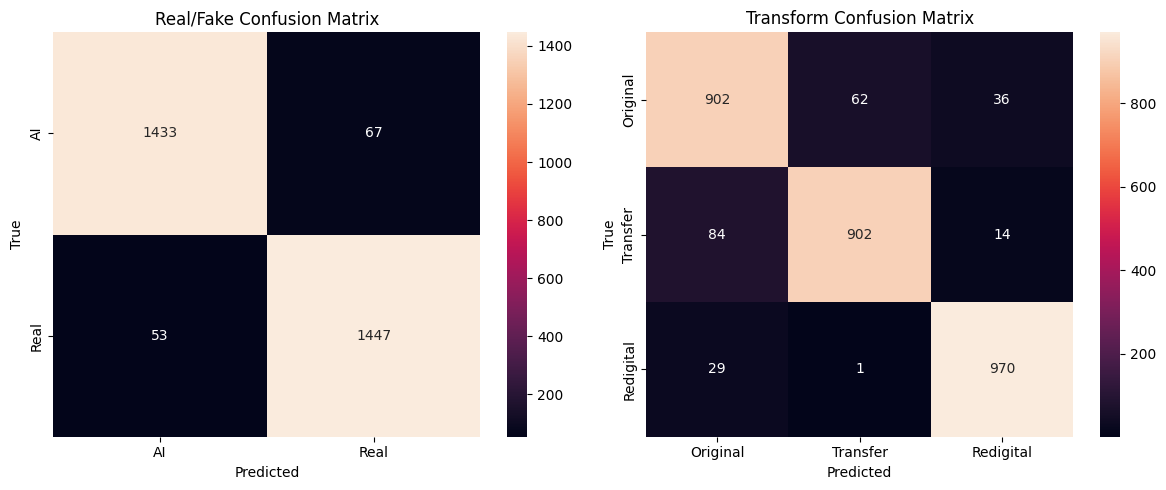


Real/Fake Classification Report:
              precision    recall  f1-score   support

          AI       0.96      0.96      0.96      1500
        Real       0.96      0.96      0.96      1500

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000

Transform Classification Report:
              precision    recall  f1-score   support

    Original       0.89      0.90      0.90      1000
    Transfer       0.93      0.90      0.92      1000
   Redigital       0.95      0.97      0.96      1000

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_rf_preds, all_rf_labels = [], []
all_t_preds,  all_t_labels  = [], []

with torch.no_grad():
    for images, rf_labels, t_labels in val_loader:
        images = images.to(device)
        out_rf, out_t = model(images)
        all_rf_preds.extend(out_rf.argmax(1).cpu().numpy())
        all_rf_labels.extend(rf_labels.numpy())
        all_t_preds.extend(out_t.argmax(1).cpu().numpy())
        all_t_labels.extend(t_labels.numpy())

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(all_rf_labels, all_rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[0],
            xticklabels=['AI', 'Real'],
            yticklabels=['AI', 'Real'])
axes[0].set_title('Real/Fake Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

cm_t = confusion_matrix(all_t_labels, all_t_preds)
sns.heatmap(cm_t, annot=True, fmt='d', ax=axes[1],
            xticklabels=['Original', 'Transfer', 'Redigital'],
            yticklabels=['Original', 'Transfer', 'Redigital'])
axes[1].set_title('Transform Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# --- F1 scores ---
print('\nReal/Fake Classification Report:')
print(classification_report(all_rf_labels, all_rf_preds,
      target_names=['AI', 'Real']))

print('Transform Classification Report:')
print(classification_report(all_t_labels, all_t_preds,
      target_names=['Original', 'Transfer', 'Redigital']))

## STEP 11 — Ablation Study (different alpha/beta weights)

In [14]:
# Training joint model with two more weight combinations
# We already have alpha=0.5, beta=0.5 (the default)
# Now trying alpha=0.8/beta=0.2 (favour real/fake) and alpha=0.2/beta=0.8 (favour transform)

ablation_results = {}
EPOCHS = 5

for alpha, beta in [(0.8, 0.2), (0.2, 0.8)]:
    print(f'\nTraining with alpha={alpha}, beta={beta}')
    m = MultiTaskModel().to(device)
    opt = optim.Adam(m.parameters(), lr=1e-4)
    sch = StepLR(opt, step_size=3, gamma=0.5)

    for epoch in range(EPOCHS):
        train_epoch(m, train_loader, opt, alpha=alpha, beta=beta)
        sch.step()

    _, vl_rf, vl_t = val_epoch(m, val_loader, alpha=alpha, beta=beta)
    ablation_results[f'a={alpha}_b={beta}'] = {'val_rf': vl_rf, 'val_t': vl_t}
    print(f'  Val RF: {vl_rf:.4f} | Val T: {vl_t:.4f}')

# Add original results
_, vl_rf_orig, vl_t_orig = val_epoch(model, val_loader)
ablation_results['a=0.5_b=0.5'] = {'val_rf': vl_rf_orig, 'val_t': vl_t_orig}

print('\n--- Ablation Summary ---')
print(f"{'Weights':<15} {'Val RF Acc':<12} {'Val T Acc'}")
print('-' * 40)
for name, r in ablation_results.items():
    print(f"{name:<15} {r['val_rf']:<12.4f} {r['val_t']:.4f}")


Training with alpha=0.8, beta=0.2
  Val RF: 0.9467 | Val T: 0.8923

Training with alpha=0.2, beta=0.8
  Val RF: 0.9383 | Val T: 0.9140

--- Ablation Summary ---
Weights         Val RF Acc   Val T Acc
----------------------------------------
a=0.8_b=0.2     0.9467       0.8923
a=0.2_b=0.8     0.9383       0.9140
a=0.5_b=0.5     0.9600       0.9247


In [16]:
from google.colab import files
##files.download('training_curves.png')
files.download('confusion_matrices.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>